<a href="https://colab.research.google.com/github/bburugap/ores5160-2026/blob/main/week9/week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


In [2]:
from google.colab import drive
drive.mount('/content/drive')
CSV_FILE="/content/drive/MyDrive/HDS5210-2025/week07/est2018-pop-res.csv"


Mounted at /content/drive


In [3]:

#Q1 1.  Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

with open(CSV_FILE, 'r') as f:
    reader = csv.reader(f)

    for i, row in enumerate(reader):
        print(row)
        if i == 4:
            break

['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']
['010', '0', '0', '00', 'United States', '327167434', '253768092', '77.6']
['040', '3', '6', '01', 'Alabama', '4887871', '3798031', '77.7']
['040', '4', '9', '02', 'Alaska', '737438', '553622', '75.1']
['040', '4', '8', '04', 'Arizona', '7171646', '5528989', '77.1']


In [4]:
# Q1 2. Then use pandas.read_csv() to load the same file into a DataFrame.
import pandas as pd

pop = pd.read_csv(CSV_FILE)

In [5]:
#Q1 2.1 Display the shape (rows × columns).
print(pop.shape)

(53, 8)


In [6]:
#Q1 2.2 Print the list of column names.

print(pop.columns.tolist())

['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']


In [7]:
#Q1 3. Which column represents total population? Display the top 5 most populous states

#Creating new DataFrame removing UnitedStates from the list
filtered = pop[pop['NAME'] != 'United States']

#Sorting and priting the top 5 results from above filted data frame
top5 = filtered.sort_values(by='POPESTIMATE2018', ascending=False).head(5)

print(top5[['NAME', 'POPESTIMATE2018']])

            NAME  POPESTIMATE2018
5     California         39557045
44         Texas         28701845
10       Florida         21299325
33      New York         19542209
39  Pennsylvania         12807060


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

In [8]:
#Q2. 1. Compute the average population across all states
avg_pop = filtered['POPESTIMATE2018'].mean()

print("Average population:", avg_pop)

Average population: 6353126.673076923


In [9]:
#Q2. 2. Find which region has the highest total population.
region_pop = filtered.groupby('REGION')['POPESTIMATE2018'].sum()
top_region = region_pop.sort_values(ascending=False).head(1)
print(top_region)

REGION
3    124753948
Name: POPESTIMATE2018, dtype: int64


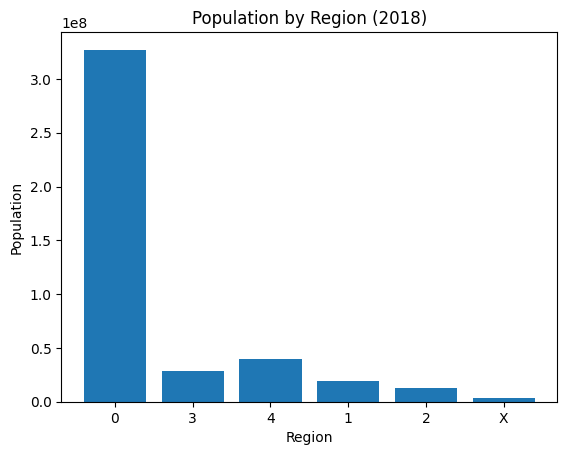

In [10]:
##Q2. 3. Plot a bar chart showing the population by region (use matplotlib)

import matplotlib.pyplot as plt

# Extract region names and populations
region_names = pop['REGION']
population = pop['POPESTIMATE2018']

# Plot
plt.figure()
plt.bar(region_names, population)

plt.xlabel('Region')
plt.ylabel('Population')
plt.title('Population by Region (2018)')

plt.show()

Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

In [ ]:
import json
from pathlib import Path
Patient_File="/content/drive/MyDrive/HDS5210-2025/week07/patient.json"

In [ ]:
#Q3. 1. Load patient.json into a Python dictionary
import json

with open(Patient_File) as f:
    data = json.load(f)

In [ ]:
# Q3, 2.1. Full official name
for name in data['name']:
    if name.get('use') == 'official':
        full_name = " ".join(name.get('given', [])) + " " + name.get('family', '')
        print("Patient Full Official Name:", full_name)


Patient Full Official Name: Peter James Chalmers


In [ ]:
# Q3 2.2 Gender and birth date
print("Gender:", data.get('gender'))
print("Birth Date:", data.get('birthDate'))

Gender: male
Birth Date: 1974-12-25


In [ ]:
#Q3 2.3 Current address
if 'address' in data and len(data['address']) > 0:
    addr = data['address'][0]
    street = " ".join(addr.get('line', []))  # join list into string
    print("Street:", street)
    print("City:", addr.get('city'))
    print("State:", addr.get('state'))
    print("Postal Code:", addr.get('postalCode'))

Street: 534 Erewhon St
City: PleasantVille
State: Vic
Postal Code: 3999


In [ ]:
#Q3 3. Count phone numbers and list their types
phone_types = []

for telecom in data.get('telecom', []):
    if telecom.get('system') == 'phone':
        phone_types.append(telecom.get('use'))

print("Number of phone numbers:", len(phone_types))
print("Phone types:", phone_types)

Number of phone numbers: 3
Phone types: ['work', 'mobile', 'old']
